In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Importing Data

In [2]:
rent_df = pd.read_csv("apartments_for_rent_classified_10K.csv", sep=';', encoding='latin1', na_values=['null'])
rent_df.drop(columns=['id'], inplace=True)
rent_df.head()

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,NaN,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,NaN,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,NaN,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,NaN,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,NaN,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [3]:
rent_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   category       10000 non-null  object 
 1   title          10000 non-null  object 
 2   body           10000 non-null  object 
 3   amenities      6451 non-null   object 
 4   bathrooms      9966 non-null   float64
 5   bedrooms       9993 non-null   float64
 6   currency       10000 non-null  object 
 7   fee            10000 non-null  object 
 8   has_photo      10000 non-null  object 
 9   pets_allowed   5837 non-null   object 
 10  price          10000 non-null  int64  
 11  price_display  10000 non-null  object 
 12  price_type     10000 non-null  object 
 13  square_feet    10000 non-null  int64  
 14  address        6673 non-null   object 
 15  cityname       9923 non-null   object 
 16  state          9923 non-null   object 
 17  latitude       9990 non-null   float64
 18  longitu

In [4]:
rent_df.describe()

,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [5]:
rent_df.isna().sum()

category            0
title               0
body                0
amenities        3549
bathrooms          34
bedrooms            7
currency            0
fee                 0
has_photo           0
pets_allowed     4163
price               0
price_display       0
price_type          0
square_feet         0
address          3327
cityname           77
state              77
latitude           10
longitude          10
source              0
time                0
dtype: int64

In [6]:
cols_to_drop = ['id', 'title', 'body', 'address', 'currency', 'fee', 'category', 'price_type', 'price_display', 'cityname', 'state', 'source', 'has_photo', 'time', 'amenities', 'pets_allowed']
rent_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
rent_df.head()

,bathrooms,bedrooms,price,square_feet,latitude,longitude
0,NaN,0.0,790,101,38.9057,-76.9861
1,NaN,1.0,425,106,37.9680,-87.6621
2,1.0,0.0,1390,107,38.8910,-77.0816
3,1.0,0.0,925,116,47.6160,-122.3275
4,NaN,0.0,880,125,38.8738,-77.1055


# EDA

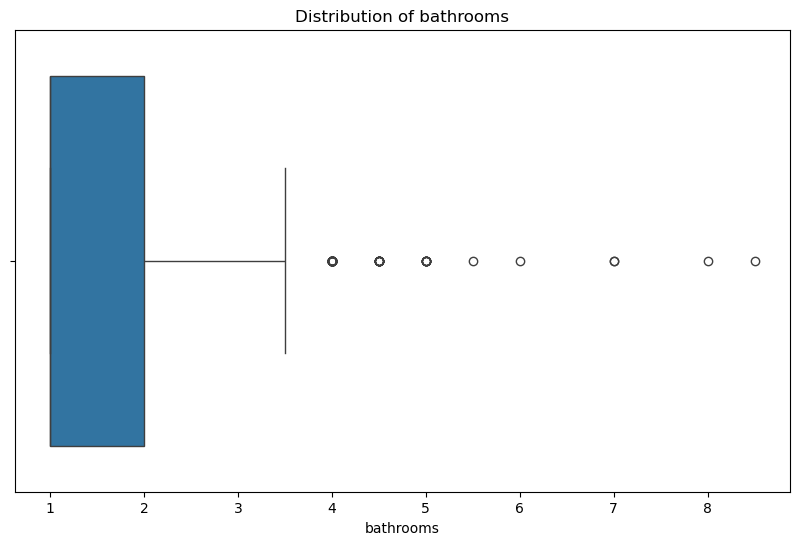

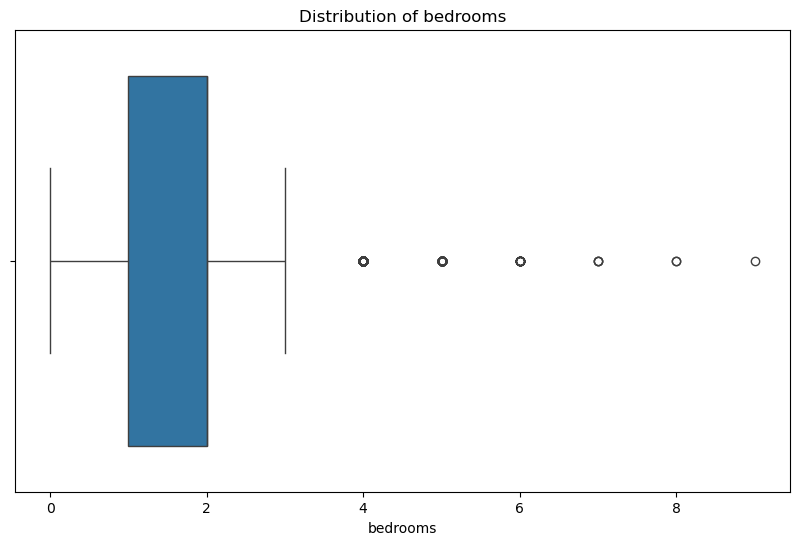

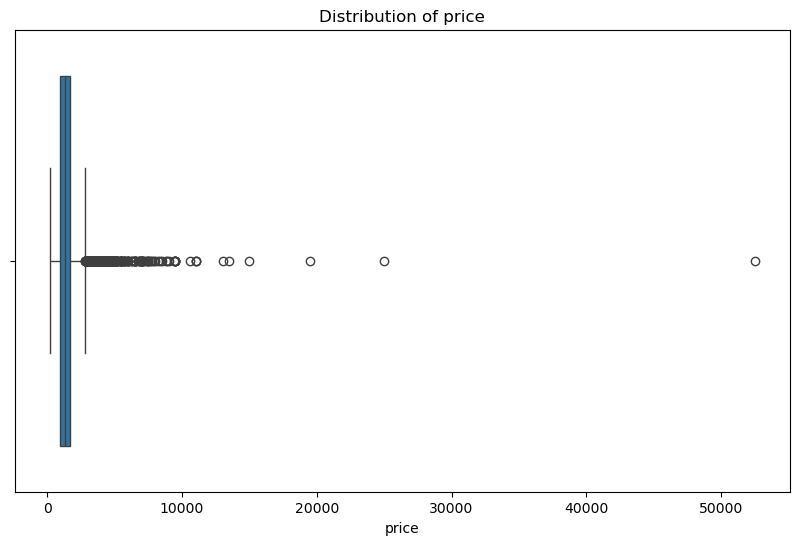

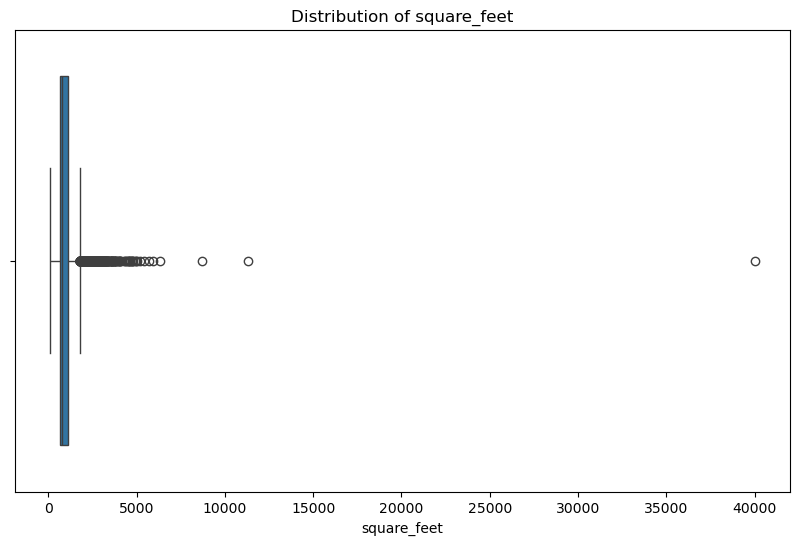

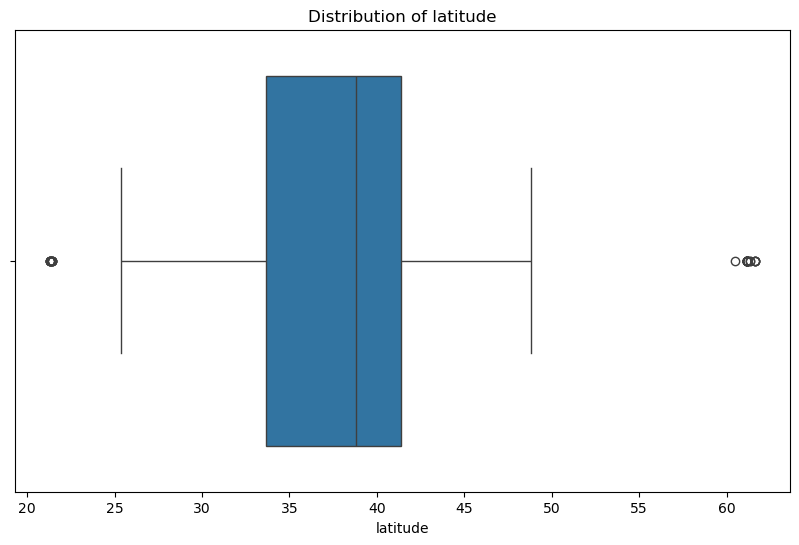

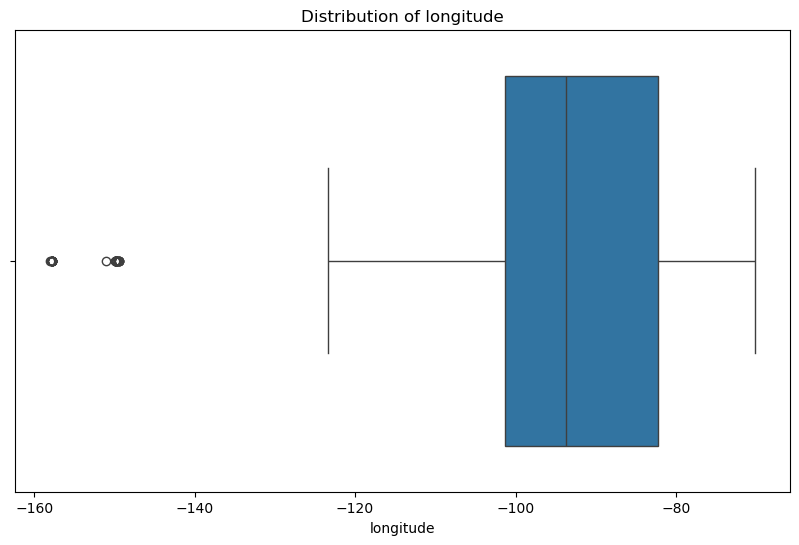

In [7]:
num_cols = rent_df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=rent_df, x=col, orient='h')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()

In [8]:
# scale dataset with Robust Scaler
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaled_data = scaler.fit_transform(rent_df)
scaled_df = pd.DataFrame(scaled_data,columns=rent_df.columns)
scaled_df.head()

,bathrooms,bedrooms,price,square_feet,latitude,longitude
0,NaN,-2.0,-0.643432,-1.554324,0.012503,0.872917
1,NaN,-1.0,-1.132708,-1.543237,-0.109753,0.313722
2,0.0,-2.0,0.160858,-1.541020,0.010587,0.867915
3,0.0,-2.0,-0.462466,-1.521064,1.148143,-1.502007
4,NaN,-2.0,-0.522788,-1.501109,0.008344,0.866663


## K-means algorithm

In [9]:
##k